/var/folders/z0/qqrtrrn92vbdtswsgx1tzsmm0000gn/T/ipykernel_7212/1453823554.py:29: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_path)


001 / 800
002 / 800
003 / 800
004 / 800
005 / 800
006 / 800
007 / 800
008 / 800
009 / 800
010 / 800
011 / 800
012 / 800
013 / 800
014 / 800
015 / 800
016 / 800
017 / 800
018 / 800
019 / 800
020 / 800
021 / 800
022 / 800
023 / 800
024 / 800
025 / 800
026 / 800
027 / 800
028 / 800
029 / 800
030 / 800
031 / 800
032 / 800
033 / 800
034 / 800
035 / 800
036 / 800
037 / 800
038 / 800
039 / 800
040 / 800
041 / 800
042 / 800
043 / 800
044 / 800
045 / 800
046 / 800
047 / 800
048 / 800
049 / 800
050 / 800
051 / 800
052 / 800
053 / 800
054 / 800
055 / 800
056 / 800
057 / 800
058 / 800
059 / 800
060 / 800
061 / 800
062 / 800
063 / 800
064 / 800
065 / 800
066 / 800
067 / 800
068 / 800
069 / 800
070 / 800
071 / 800
072 / 800
073 / 800
074 / 800
075 / 800
076 / 800
077 / 800
078 / 800
079 / 800
080 / 800
081 / 800
082 / 800
083 / 800
084 / 800
085 / 800
086 / 800
087 / 800
088 / 800
089 / 800
090 / 800
091 / 800
092 / 800
093 / 800
094 / 800
095 / 800
096 / 800
097 / 800
098 / 800
099 / 800
100 / 800


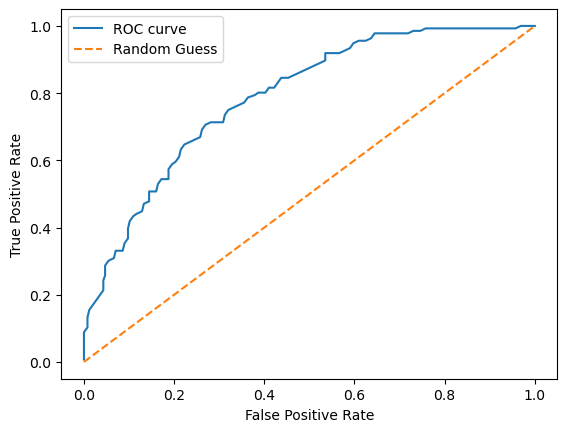

AUC: 0.7917336856617647


In [1]:
import os
import numpy as np
import pandas as pd
import imageio
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Read metadata ---
# Set the file path for metadata
meta_path = os.path.join(os.path.expanduser("~"), "Desktop", "MATH 3333", "Project", "photoMetaData.csv")
pm = pd.read_csv(meta_path)
n = pm.shape[0]

# Create a random train/test split flag (True = train, False = test)
trainFlag = np.random.rand(n) > 0.5

# Outcome: binary indicator of whether the category equals "outdoor-day"
y = (pm['category'] == 'outdoor-day').astype(int).values

# --- Read images and compute predictors ---
# Initialize X to store 3 medians for each image
X = np.empty((n, 3))
# Directory containing the images
image_dir = os.path.join(os.path.expanduser("~"), "Desktop", "MATH 3333", "Project", "columbiaImages")

for j in range(n):
    # Construct the full image file path using the name from metadata
    image_path = os.path.join(image_dir, pm.loc[j, 'name'])
    img = imageio.imread(image_path)
    # Compute median of pixel intensities for each color channel
    # (R, G, B) are assumed to be in the third dimension.
    medians = np.median(img, axis=(0, 1))
    X[j, :] = medians
    print(f"{j+1:03d} / {n:03d}")

# --- Logistic Regression Model ---
# Add a constant term (intercept) to the predictors
X_const = sm.add_constant(X)
# Subset training data based on trainFlag
X_train = X_const[trainFlag]
y_train = y[trainFlag]

# Fit the logistic regression (GLM with binomial family)
model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
result = model.fit()

# Print the iteration count if available, and the summary of the fitted model
try:
    print("Iterations:", result.iterations)
except AttributeError:
    print("Iteration count not available")
print(result.summary())

# --- Predictions and Evaluation ---
# Compute predictions on the full dataset
pred = 1 / (1 + np.exp(-X_const.dot(result.params)))

# Order outcomes by the predicted probability (for both train and test sets)
ordered_train = y[np.argsort(pred)]
ordered_test = y[~trainFlag][np.argsort(pred[~trainFlag])]

print("Ordered outcomes for the training set:")
print(ordered_train)
print("Ordered outcomes for the test set:")
print(ordered_test)

# Calculate accuracy for train and test sets using 0.5 as the cutoff
train_acc = np.mean(((pred > 0.5).astype(int))[trainFlag] == y[trainFlag])
test_acc = np.mean(((pred > 0.5).astype(int))[~trainFlag] == y[~trainFlag])
print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)

# --- ROC Curve and AUC ---
def roc(y_true, pred_probs):
    # Define threshold values from 0 to 1 in 0.01 increments
    alphas = np.quantile(pred_probs, np.linspace(0, 1, 101))
    sens = []
    spec = []
    for alpha in alphas:
        predClass = (pred_probs >= alpha).astype(int)
        # Sensitivity (true positive rate)
        sens_val = np.sum((predClass == 1) & (y_true == 1)) / np.sum(y_true == 1)
        # Specificity (true negative rate)
        spec_val = np.sum((predClass == 0) & (y_true == 0)) / np.sum(y_true == 0)
        sens.append(sens_val)
        spec.append(spec_val)
    return {'fpr': 1 - np.array(spec), 'tpr': np.array(sens)}

# Compute ROC for the test set predictions
roc_result = roc(y[~trainFlag], pred[~trainFlag])
plt.plot(roc_result['fpr'], roc_result['tpr'], label='ROC curve')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.legend()
plt.show()

def auc(roc_data):
    # Calculate AUC using the sum of fpr * diff(0, tpr)
    fpr = roc_data['fpr']
    tpr = roc_data['tpr']
    dtpr = np.diff(np.concatenate(([0], tpr)))
    return np.sum(fpr * dtpr)

glmAuc = auc(roc_result)
print("AUC:", glmAuc)